# Agenda

Unsupervised learning - Intro, Clustering, Scaling, Dimensionality reduction (PCA, t-SNE or UMAP), Association Rule Learning, Anomaly / Outlier Detection, Representation Learning.

<br>
Clustering - K-means - how it works

Hyperparameters

Evaluation metrics

Why Clustering ?

Code demo

Advantages and Disadvantages


DBSCAN - how it works

Code demo

Advantages and Disadvantages


Hierarchical, Agglomerative

<br>
PCA - intro

How it works

Benefits

Code demo

# Unsupervised Learning

In unsupervised learning, there are no output labels.

The model tries to find hidden patterns or structure in data.

<b> Finds natural groupings or relationships in data without needing labels. </b>

Example: Customer segments with similar buying behavior, or document topics in a news dataset.

Works even when labeled data is unavailable or expensive to collect.

Ideal for domains like biology, medicine, or security, where labeling is slow or requires experts.

Automatically organizes massive unstructured data (images, text, logs).

Helps summarize and visualize high-dimensional data using PCA, t-SNE, or UMAP.

Useful as an exploratory data analysis (EDA) tool before applying supervised methods.

<b> Detects unusual behaviors or data points automatically. </b>

<b> Association rule mining (like Apriori) reveals “if-then” relationships among variables. </b>

Valuable for cross-selling, recommendation, and marketing.

<b> Can act as a pre-step before classification or regression </b>

Use clustering to label data into pseudo-classes.

Use PCA to simplify data and remove noise.

Since no labels are required, data collection costs are low.

Algorithms can scale well to millions of records using modern compute power.

Excellent for big data analytics in business intelligence and IoT.

# K - means

### Step 1: Choose the number of clusters (K)

You decide how many groups (K) you want to divide the data into.

Example:
If you have customer data, you might want to group them into K = 3 segments (e.g., Low-spend, Medium-spend, High-spend).

### Step 2: Initialize centroids randomly

Randomly select K points from the dataset as the initial centroids (cluster centers).

If K = 3, randomly pick 3 data points as starting centers C_1, C_2, C_3.

### Step 3: Assign each point to the nearest centroid

For each data point, calculate its distance to all centroids.

Assign the point to the cluster whose centroid is closest.

Common distance measure: Euclidean (Refer distance_metrics.ipynb)

### Step 4: Update centroids

After assigning all points to clusters, compute new centroids by taking the mean (average) of all points in each cluster.

Example: 
If Cluster 1 has points (1,2), (2,3), (3,4) → New centroid = (mean of x, mean of y) = (2, 3).

### Step 5: Repeat Steps 3 and 4

Reassign points to the nearest new centroids.

Then recalculate centroids again.

### Repeat this process until

Centroids stop changing, or

Assignments of points to clusters no longer change, or

You reach a maximum number of iterations.

### Step 6: Convergence and Final Clusters

Once the centroids stabilize, the algorithm converges.

You now have K final clusters and their centroids.

##### The objective function minimized : Sum of squared distances between points and their respective cluster centers.

<img src="./images/k_means_9.png" alt="sample" width="1000"/>

<img src="./images/k_means_1.png" alt="sample" width="1000"/>

<img src="./images/k_means_2.png" alt="sample" width="1000"/>

<img src="./images/k_means_3.png" alt="sample" width="1000"/>

<img src="./images/k_means_4.png" alt="sample" width="1000"/>

<img src="./images/k_means_5.png" alt="sample" width="1000"/>

<img src="./images/k_means_6.png" alt="sample" width="1000"/>

<img src="./images/k_means_7.png" alt="sample" width="1000"/>

<img src="./images/k_means_8.png" alt="sample" width="1000"/>

# Significant hyperparameter - n_init

n_init = Number of initializations (random starting points) that the K-Means algorithm will run.

Every time you run K-Means, it:

1.	Randomly chooses K initial centroids.</t>

2.	Runs the algorithm until convergence (centroids stop moving).

3.	Computes the total inertia (sum of squared distances).

Because the initialization is random, different runs may lead to different results — sometimes a bad local minimum (poor clustering).

KMeans(n_clusters=3, n_init=10)

That means:

The algorithm runs 10 independent initializations.
	
Each run produces its own final clusters and inertia value.
	
It then keeps the best one — the one with the lowest inertia (tightest clusters).

✅ So n_init improves reliability and avoids unlucky random starting points.

Use n_init=10 or n_init=20 for small–medium datasets (like Iris).

For larger or critical analyses, n_init=50 ensures robustness.

# Evaluation metrics

#### 1) Silhoutte score

It measures how well a data point fits within its assigned cluster compared to other clusters.

It tells you how similar an object is to its own cluster (cohesion) and how different it is from other clusters (separation).


<img src="./images/silhoutte_score_1.png" alt="sample" width="1000"/>



Where

a(i) = average distance from point i to all other points in the same cluster (measures cohesion).

b(i) = average distance from point i to all points in the nearest neighboring cluster (measures separation).

The Silhouette score for the dataset is the average of all individual s(i) values.

<b> Interpretation of values </b>

+1 : Perfect separation — point is very close to its own cluster, far from others : Excellent

0 : Borderline — point is on or near the boundary between clusters : Weak / Overlapping

–1 : Misclassified — point is closer to another cluster than its own : Poor


#### 2) Inertia


Inertia (also called Within-Cluster Sum of Squares, or WCSS) measures how tightly the data points are grouped around their cluster centroids.

Formally, it’s the sum of squared distances between each data point and its assigned cluster center.

<img src="./images/inertia_1.png" alt="sample" width="1000"/>


Where:

K: number of clusters

#### 3) Adjusted rand index

ARI tells you how well your clustering algorithm grouped similar items together, compared to the actual, known categories.

Example :

Suppose you cluster the Iris dataset (which has 3 species) :

Your K-Means model groups the data into 3 clusters.

You compare those cluster assignments to the true species labels using ARI and you get value like this:

Adjusted Rand Index: 0.73

That means your clustering captures 73% of the true grouping structure after adjusting for chance — a strong result.

# Why should I use ARI given that Clustering is unsupervised learning ?

Even if you already have external labels, clustering can still be very useful for:

Exploration,

Validation, and

Discovery of new or hidden patterns beyond your labeled categories.

Even with labels, clustering can answer:

Are my labeled classes naturally separable in feature space?

Do my labels correspond to real statistical groupings?

Are there subgroups within a single label that I didn’t know existed?

In the Iris dataset, there are 3 species labels (Setosa, Versicolor, Virginica).
But clustering shows that Setosa forms a distinct, tight group, while Versicolor and Virginica overlap — revealing biological similarity between those two species.

So, clustering helps validate label quality and detect overlaps or ambiguities.

In practice, labeled data:

Might be incorrectly labeled (human error, bias)

Might be too broad (one label covers multiple hidden patterns)

Might be missing for new data

✅ Clustering helps you audit and refine your labels

Detect mislabeled samples (e.g., points far from their cluster)

Suggest relabeling or merging/splitting categories

📘 Example:
In customer segmentation:

You might already label customers as “High-value” or “Low-value.”

But clustering may reveal 3–4 natural segments based on behavior, showing that “High-value” customers actually form two different subgroups.


Clustering is useful for feature learning & preprocessing

Example: cluster similar products, genes, or users — then use the cluster index as a new categorical feature in your supervised model.

Use case:
In fraud detection or recommendation systems, you might:

Cluster users by transaction behavior

Use those cluster IDs as input features to your classifier

This often boosts model performance.


# Code demo

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 

K candidates: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Silhouette scores: [np.float64(0.5818), np.float64(0.4599), np.float64(0.3869), np.float64(0.3459), np.float64(0.3171), np.float64(0.3202), np.float64(0.3387), np.float64(0.3424), np.float64(0.3518)]
Best K by silhouette: 2



/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

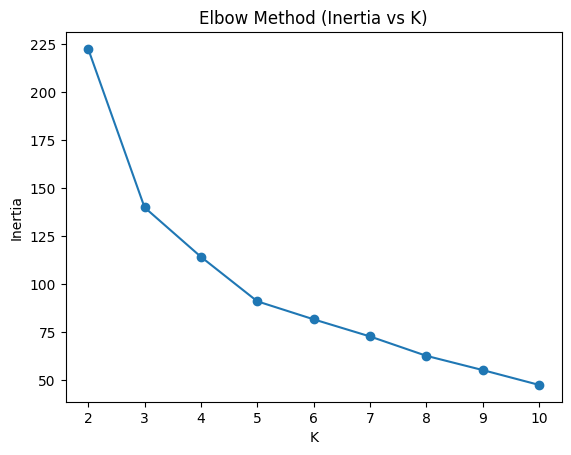

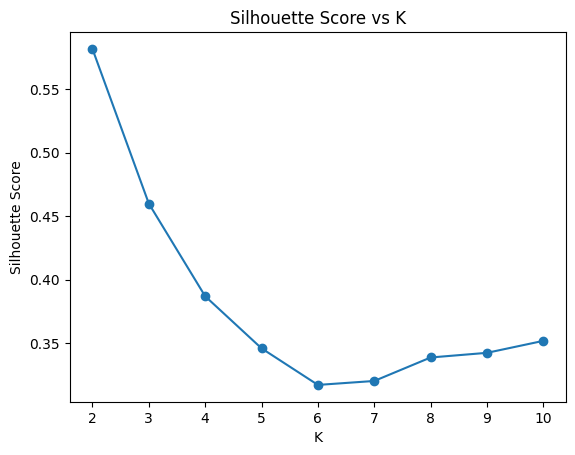

Final K = 2
Silhouette Score: 0.5818
Adjusted Rand Index (vs true species): 0.5681

Cluster Centers (original feature scale):
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster 0               6.26              2.87               4.91   
Cluster 1               5.01              3.43               1.46   

           petal width (cm)  
Cluster 0              1.68  
Cluster 1              0.25  


In [15]:
# K-Means on a real-world dataset: IRIS (UCI)
# ---------------------------------------------------------
# What you'll get:
# 1) Load & scale data
# 2) Choose K using Elbow + Silhouette
# 3) Fit KMeans
# 4) Evaluate with Silhouette, ARI, NMI

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# 1) Load dataset
iris = load_iris()
X = iris.data
y_true = iris.target  # only for evaluation (KMeans is unsupervised)
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
print("First 5 rows:")
print(df.head(), "\n")

# 2) Scale features (important for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Choose K — Elbow & Silhouette
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k_sil = K_range[int(np.argmax(sil_scores))]

print("K candidates:", list(K_range))
print("Silhouette scores:", [round(s, 4) for s in sil_scores])
print(f"Best K by silhouette: {best_k_sil}\n")

# Plot Elbow (Inertia) and Silhouette
plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

# 4) Fit final KMeans with chosen K
k_final = best_k_sil  # you can override if elbow suggests otherwise
kmeans = KMeans(n_clusters=k_final, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# 5) Evaluate (unsupervised metrics; y_true only for reference)
sil = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(y_true, cluster_labels)   # external metric (needs true labels)

print(f"Final K = {k_final}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index (vs true species): {ari:.4f}")

# 6) Inspect cluster centers in original feature space (inverse scale)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=feature_names)
centers_df.index = [f"Cluster {i}" for i in range(k_final)]
print("\nCluster Centers (original feature scale):")
print(centers_df.round(2))

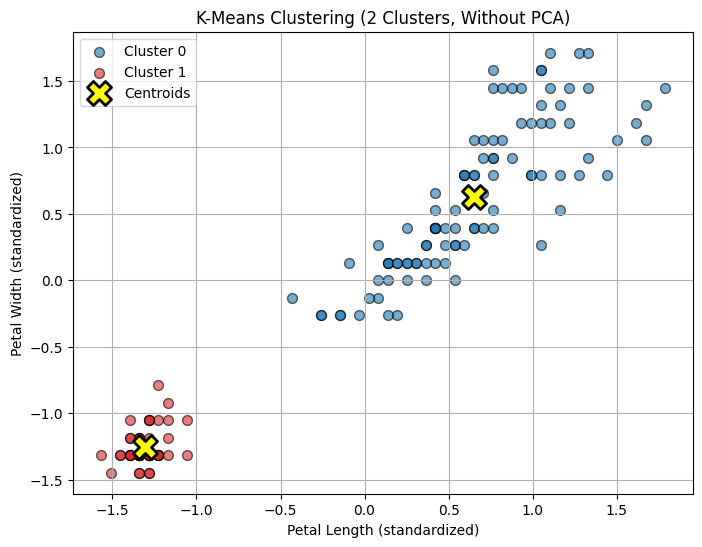

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1) Load dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)

# 2) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Apply KMeans (2 clusters)
kmeans = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# 4) Choose two features for plotting (Petal Length vs Petal Width)
x_index = feature_names.index('petal length (cm)')
y_index = feature_names.index('petal width (cm)')

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#d62728']  # exactly two colors

# Plot the clusters (data points) — iterate over actual labels
for i, color in enumerate(colors[:kmeans.n_clusters]):
    pts = X_scaled[labels == i]
    plt.scatter(pts[:, x_index], pts[:, y_index],
                s=50, c=color, label=f'Cluster {i}', alpha=0.6, edgecolor='k')

# Plot the centroids (in standardized feature space)
plt.scatter(centroids[:, x_index], centroids[:, y_index],
            s=300, c='yellow', marker='X', edgecolor='black', linewidth=2, label='Centroids')

# Labels and legend
plt.title("K-Means Clustering (2 Clusters, Without PCA)")
plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.legend()
plt.grid(True)
plt.show()

# Advantages

Conceptually straightforward — based on minimizing distances between points and centroids.

Works fast on large datasets because it uses simple distance-based calculations.

The algorithm monotonically reduces inertia at every iteration and guarantees convergence.

Performs very well when clusters are compact and roughly circular in shape.

Centroids represent the “average” member of each cluster — intuitive to interpret and visualize.

Widely used in image compression, document grouping, market segmentation, and anomaly detection.

Cluster IDs can be used as categorical features in supervised models to capture group-based relationships.

# Disadvantages

You need to choose K manually or use methods like the Elbow or Silhouette, which can be subjective.

Different initial centroid positions can lead to different results (mitigated by k-means++ and n_init).

K-Means only works well when clusters are circular and have similar variance — fails with elongated or irregular shapes.

Outliers can pull centroids far from true cluster centers because the mean is affected by extreme values.

Doesn’t handle clusters of varying densities or non-convex boundaries (e.g., concentric rings).

Doesn’t work well with categorical or mixed data unless you preprocess or modify the distance function.

Because it uses Euclidean distance, unscaled data can make features with larger ranges dominate results.

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### Step 1: Set two rules

You first define two parameters:

ε (epsilon) → how close points must be to be considered “neighbors.”

min_samples → how many neighbors a point must have to be considered part of a dense region (a cluster).

Example:

“If a point has at least 5 neighbors within 2 cm distance → it’s part of a cluster.”

### Step 2: Pick any unvisited point

Start with a random point that hasn’t been looked at yet.

### Step 3: Check its neighborhood

Look around this point — find all points that lie within the distance ε.

### Step 4: Decide what type of point it is

If it has enough neighbors (≥ min_samples) → it’s a core point (center of a dense area).

If it has fewer neighbors → it’s a border point (edge of a cluster) or noise (outlier).

### Step 5: If it’s a core point → grow a cluster

Start a new cluster with this point.

Add all its neighboring points to the same cluster.

For each neighbor that is also a core point, repeat the process — include its neighbors too.

👉 This way, the cluster expands like a spreading wave through dense regions.

### Step 6: Move to the next unvisited point

If that point belongs to a cluster → skip it.

If not, check if it can start a new cluster (if dense) or mark it as noise.

### Step 7: Continue until all points are checked

When all points are visited:

You have your clusters (groups of dense points).

Isolated points that didn’t belong anywhere are noise/outliers.

# How it works

<img src="./images/dbscan_1.png" alt="sample" width="1000"/>


<img src="./images/dbscan_2.png" alt="sample" width="1000"/>


<img src="./images/dbscan_3.png" alt="sample" width="1000"/>


<img src="./images/dbscan_4.png" alt="sample" width="1000"/>


<img src="./images/dbscan_5.png" alt="sample" width="1000"/>


<img src="./images/dbscan_6.png" alt="sample" width="1000"/>


<img src="./images/dbscan_7.png" alt="sample" width="1000"/>


<img src="./images/dbscan_8.png" alt="sample" width="1000"/>


<img src="./images/dbscan_9.png" alt="sample" width="1000"/>


<img src="./images/dbscan_10.png" alt="sample" width="1000"/>


<img src="./images/dbscan_11.png" alt="sample" width="1000"/>


<img src="./images/dbscan_12.png" alt="sample" width="1000"/>


<img src="./images/dbscan_13.png" alt="sample" width="1000"/>


<img src="./images/dbscan_14.png" alt="sample" width="1000"/>


<img src="./images/dbscan_15.png" alt="sample" width="1000"/>


<img src="./images/dbscan_16.png" alt="sample" width="1000"/>


<img src="./images/dbscan_17.png" alt="sample" width="1000"/>


<img src="./images/dbscan_18.png" alt="sample" width="1000"/>


<img src="./images/dbscan_19.png" alt="sample" width="1000"/>


<img src="./images/dbscan_20.png" alt="sample" width="1000"/>


# Code demo

eps=0.7, min_samples=5
Clusters (excluding noise): 2
Noise points: 6
Silhouette (non-noise only): 0.602


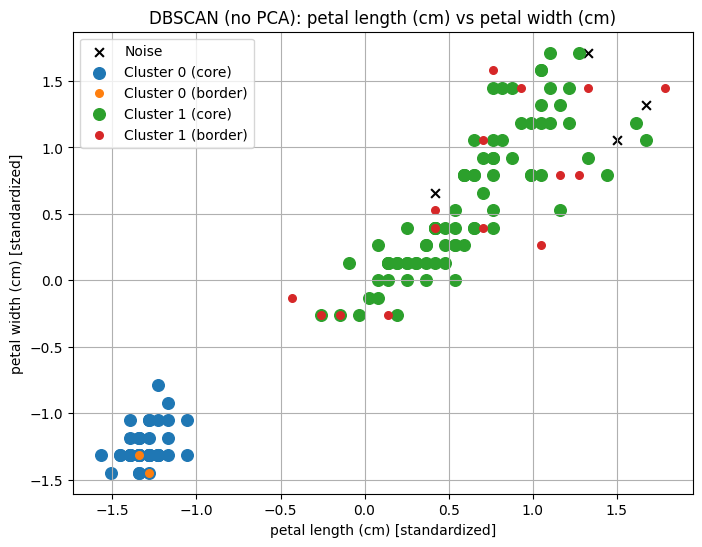

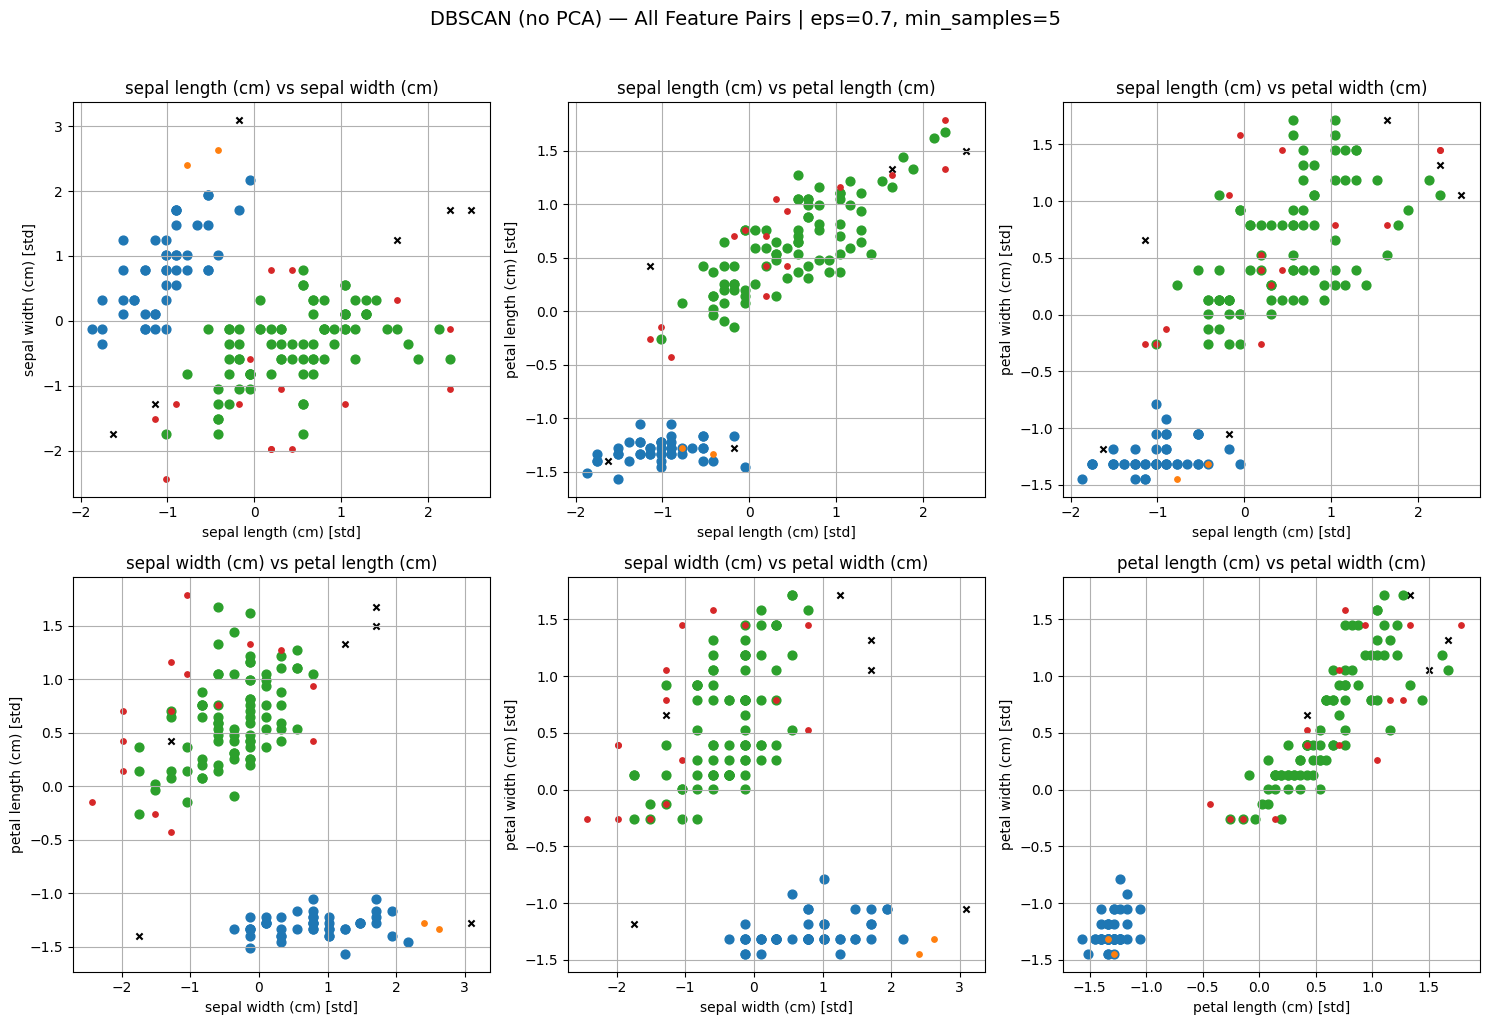

In [10]:
# DBSCAN on Iris — visualize WITHOUT PCA (original feature space)
# ---------------------------------------------------------------
# 1) Single 2D plot (choose any two features)
# 2) All-pairs grid (6 subplots for 4D -> 2D pairs)
#
# Tip: Tweak eps/min_samples to see how clusters/noise change.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1) Load & scale
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) DBSCAN params (manual)
eps = 0.7
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
labels = db.fit_predict(X_scaled)

# Identify core points for styling
core_mask = np.zeros_like(labels, dtype=bool)
if hasattr(db, "core_sample_indices_"):
    core_mask[db.core_sample_indices_] = True

# Basic stats
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
print(f"eps={eps}, min_samples={min_samples}")
print(f"Clusters (excluding noise): {n_clusters}")
print(f"Noise points: {n_noise}")
if n_clusters >= 2 and np.any(labels != -1):
    sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    print(f"Silhouette (non-noise only): {sil:.3f}")

# -----------------------------
# 1) Single 2D plot (no PCA)
#    Choose two original features
# -----------------------------
x_name = 'petal length (cm)'
y_name = 'petal width (cm)'
xi = feature_names.index(x_name)
yi = feature_names.index(y_name)

plt.figure(figsize=(8, 6))
unique_labs = sorted(set(labels))

for c in unique_labs:
    mask = labels == c
    if c == -1:
        # noise
        plt.scatter(X_scaled[mask, xi], X_scaled[mask, yi],
                    s=40, marker='x', c='k', label='Noise')
    else:
        mask_core = mask & core_mask
        mask_border = mask & (~core_mask)
        # core points: bigger markers
        plt.scatter(X_scaled[mask_core, xi], X_scaled[mask_core, yi],
                    s=70, label=f"Cluster {c} (core)")
        # border points: smaller markers
        plt.scatter(X_scaled[mask_border, xi], X_scaled[mask_border, yi],
                    s=30, label=f"Cluster {c} (border)")

plt.title(f"DBSCAN (no PCA): {x_name} vs {y_name}")
plt.xlabel(f"{x_name} [standardized]")
plt.ylabel(f"{y_name} [standardized]")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------------
# 2) All-pairs grid: every feature pair
#    (helps you see structure in any 2D slice)
# -----------------------------------------
pairs = list(combinations(range(X.shape[1]), 2))
n_plots = len(pairs)  # 6 for 4 features
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.ravel()

for ax, (i, j) in zip(axes, pairs):
    for c in unique_labs:
        mask = labels == c
        if c == -1:
            ax.scatter(X_scaled[mask, i], X_scaled[mask, j],
                       s=20, marker='x', c='k')
        else:
            mask_core = mask & core_mask
            mask_border = mask & (~core_mask)
            ax.scatter(X_scaled[mask_core, i], X_scaled[mask_core, j], s=40)
            ax.scatter(X_scaled[mask_border, i], X_scaled[mask_border, j], s=15)
    ax.set_xlabel(feature_names[i] + " [std]")
    ax.set_ylabel(feature_names[j] + " [std]")
    ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")
    ax.grid(True)

# Hide any unused subplots
for k in range(len(pairs), len(axes)):
    fig.delaxes(axes[k])

fig.suptitle(f"DBSCAN (no PCA) — All Feature Pairs | eps={eps}, min_samples={min_samples}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# DBSCAN can beat K-Means on Iris by excluding ambiguous points (noise),
# producing tighter, better-separated clusters on the remaining data.

import numpy as np
import pandas as pd
from itertools import product

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# 1) Load & scale
iris = load_iris()
X = iris.data
y = iris.target
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# 2) K-Means baseline (K=3 because Iris has 3 species)
km = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
km_labels = km.fit_predict(Xz)

km_sil = silhouette_score(Xz, km_labels)
km_ari = adjusted_rand_score(y, km_labels)

print("=== K-Means Baseline (K=3) ===")
print(f"Silhouette (all points): {km_sil:.4f}")
print(f"ARI (all points vs true): {km_ari:.4f}")

# 3) DBSCAN: small manual grid to find a "good" configuration
#    (You can tweak the ranges; these work well for standardized Iris)
eps_grid = np.arange(0.35, 1.01, 0.05)
min_samples_grid = [4, 5, 6, 7]

best = {
    "sil": -1,
    "eps": None,
    "min_samples": None,
    "labels": None,
    "n_clusters": 0,
    "n_noise": 0,
    "ari": None,
    "nmi": None
}

for eps, ms in product(eps_grid, min_samples_grid):
    db = DBSCAN(eps=eps, min_samples=ms, metric='euclidean')
    labels = db.fit_predict(Xz)

    # Identify non-noise
    mask = labels != -1
    unique = sorted(set(labels) - {-1})
    n_clusters = len(unique)
    n_noise = np.sum(~mask)

    # Need at least 2 clusters and some clustered points to compute silhouette
    if n_clusters >= 2 and mask.sum() > 0:
        sil = silhouette_score(Xz[mask], labels[mask])

        # External metrics only on the clustered subset (fair comparison for DBSCAN)
        ari = adjusted_rand_score(y[mask], labels[mask])
        nmi = normalized_mutual_info_score(y[mask], labels[mask])

        if sil > best["sil"]:
            best.update(dict(sil=sil, eps=eps, min_samples=ms, labels=labels,
                             n_clusters=n_clusters, n_noise=n_noise, ari=ari, nmi=nmi))

print("=== Best DBSCAN (by Silhouette on clustered points) ===")
if best["eps"] is None:
    print("No valid DBSCAN setting produced >=2 clusters.")
else:
    print(f"eps={best['eps']:.2f}, min_samples={best['min_samples']}")
    print(f"Clusters (excl. noise): {best['n_clusters']}, Noise points: {best['n_noise']}")
    print(f"Silhouette (clustered only): {best['sil']:.4f}")
    print(f"ARI (clustered vs true): {best['ari']:.4f}")
    print(f"NMI (clustered vs true): {best['nmi']:.4f}\n")

    # 4) Head-to-head summary
    print("=== Head-to-Head Summary ===")
    print(f"K-Means Silhouette (all points):      {km_sil:.4f}")
    print(f"Best DBSCAN Silhouette (non-noise):   {best['sil']:.4f}")
    print(f"K-Means ARI (all points vs true):     {km_ari:.4f}")
    print(f"DBSCAN ARI (clustered vs true):       {best['ari']:.4f}")

    # Optional: show how many points DBSCAN clustered vs total
    total = X.shape[0]
    clustered = total - best["n_noise"]
    print(f"\nDBSCAN clustered {clustered}/{total} points "
          f"({clustered/total:.1%}); treated {best['n_noise']} as noise.")
    
    print("Noise", best["n_noise"])

=== K-Means Baseline (K=3) ===
Silhouette (all points): 0.4599
ARI (all points vs true): 0.6201
=== Best DBSCAN (by Silhouette on clustered points) ===
eps=0.50, min_samples=5
Clusters (excl. noise): 2, Noise points: 34
Silhouette (clustered only): 0.6559
ARI (clustered vs true): 0.6309
NMI (clustered vs true): 0.7602

=== Head-to-Head Summary ===
K-Means Silhouette (all points):      0.4599
Best DBSCAN Silhouette (non-noise):   0.6559
K-Means ARI (all points vs true):     0.6201
DBSCAN ARI (clustered vs true):       0.6309

DBSCAN clustered 116/150 points (77.3%); treated 34 as noise.
Noise 34


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

Total outliers: 6
Outlier data points:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.7               4.4                1.5               0.4
1                4.5               2.3                1.3               0.3
2                4.9               2.5                4.5               1.7
3                7.2               3.6                6.1               2.5
4                7.7               3.8                6.7               2.2


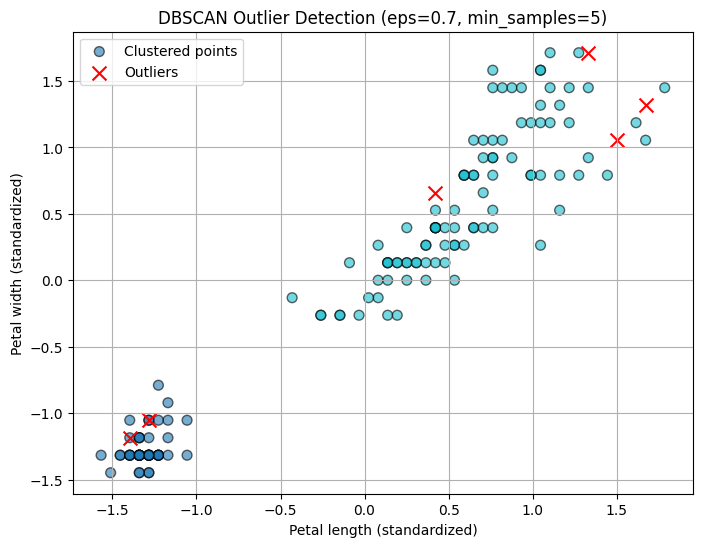

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1️⃣ Load & scale data
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2️⃣ Fit DBSCAN
eps = 0.7
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

# 3️⃣ Identify outliers (label = -1)
outliers_mask = labels == -1
outliers = X[outliers_mask]

print(f"Total outliers: {np.sum(outliers_mask)}")
print("Outlier data points:")
print(pd.DataFrame(outliers, columns=feature_names).head())

# 4️⃣ Visualize clusters vs outliers (no PCA)
x_index = feature_names.index("petal length (cm)")
y_index = feature_names.index("petal width (cm)")

plt.figure(figsize=(8,6))

# Normal clustered points
plt.scatter(X_scaled[labels != -1, x_index], X_scaled[labels != -1, y_index],
            c=labels[labels != -1], cmap="tab10", s=50, alpha=0.6, edgecolor='k', label="Clustered points")

# Outliers (-1)
plt.scatter(X_scaled[outliers_mask, x_index], X_scaled[outliers_mask, y_index],
            c='red', marker='x', s=100, label="Outliers")

plt.title(f"DBSCAN Outlier Detection (eps={eps}, min_samples={min_samples})")
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.legend()
plt.grid(True)
plt.show()

# Advantages

Unlike K-Means, DBSCAN automatically determines how many clusters exist based on data density.

Works well for circular, elongated, crescent, or irregular shapes — not limited to spherical clusters like K-Means.

Points in low-density regions are labeled as noise (label = -1) instead of being forced into a cluster.

Outlier detection is built-in — you can see which data points don’t belong anywhere.

Can cluster data like “two interlocking moons” or rings that K-Means can’t handle.

Still benefits from scaling, but not as drastically affected by extreme feature values.

Each cluster can have different shapes and sizes as long as density criteria are met.

Based on natural human idea of grouping by closeness or crowding — dense points belong together.

# Disadvantages

Wrong values can lead to either merging clusters (if eps too large) or breaking them apart (if too small).

In high dimensions, “distance” becomes less meaningful (curse of dimensionality), so DBSCAN can’t find dense areas well.

Doesn’t work well when distance (Euclidean) isn’t an appropriate similarity measure.

Slight changes in parameters or small noise can cause large changes in results.

Genuine small groups may get discarded if they don’t meet the min_samples threshold.

Depending on the order of data points, some implementations may yield slightly different results (due to neighborhood expansion).

# PCA (Principal Component Analysis)

PCA is a technique used to reduce the number of features (dimensions) in a dataset while keeping most of the important information (variance). It's a dimensionality reduction technique.

### Why we use PCA

Many features are correlated or contain redundant information.

High-dimensional data is hard to visualize and slows down model training and inferencing time.

PCA helps to simplify data, speed up learning, and sometimes improve accuracy.

### How PCA works (Intuition)

Find directions of maximum variance in the data (called principal components).

Project data onto these new directions.

Keep only the top few components that explain most of the variation.

Think of it as rotating and compressing your data into a new coordinate system where:

PC1 = direction with the most spread (information)

PC2 = next most spread, and so on

### Example

Suppose you have 10 correlated features.

PCA might find that just 3 new features (PC1, PC2, PC3) explain 95% of the information.

You can now train your model on those 3 instead of 10 — smaller, faster, but still accurate.




# How PCA works

Analyse the relationship between the feature and the target label and ensure that they have some relationship (linear or non-linear)

Drop the features which are not completely unrelated to the target variable

Analyse the relation of one feature against other features and see which features are inter-related or correlated

Drop the features which are MOSTLY related to one another

<img src="./images/pca_1.png" alt="sample" width="1000"/>

<img src="./images/pca_2.png" alt="sample" width="1000"/>

<img src="./images/pca_3.png" alt="sample" width="1000"/>

<img src="./images/pca_4.png" alt="sample" width="1000"/>

<img src="./images/pca_5.png" alt="sample" width="1000"/>

<img src="./images/pca_6.png" alt="sample" width="1000"/>

<img src="./images/pca_7.png" alt="sample" width="1000"/>

<img src="./images/pca_8.png" alt="sample" width="1000"/>

<img src="./images/pca_9.png" alt="sample" width="1000"/>

<img src="./images/pca_10.png" alt="sample" width="1000"/>

<img src="./images/pca_11.png" alt="sample" width="1000"/>

<img src="./images/pca_12.png" alt="sample" width="1000"/>

<img src="./images/pca_13.png" alt="sample" width="1000"/>

<img src="./images/pca_14.png" alt="sample" width="1000"/>

<img src="./images/pca_15.png" alt="sample" width="1000"/>

<img src="./images/pca_16.png" alt="sample" width="1000"/>

<img src="./images/pca_17.png" alt="sample" width="1000"/>

<img src="./images/pca_18.png" alt="sample" width="1000"/>

<img src="./images/pca_19.png" alt="sample" width="1000"/>

<img src="./images/pca_20.png" alt="sample" width="1000"/>

<img src="./images/pca_21.png" alt="sample" width="1000"/>

<img src="./images/pca_22.png" alt="sample" width="1000"/>

<img src="./images/pca_23.png" alt="sample" width="1000"/>

<img src="./images/pca_24.png" alt="sample" width="1000"/>

<img src="./images/pca_25.png" alt="sample" width="1000"/>

<img src="./images/pca_26.png" alt="sample" width="1000"/>

<img src="./images/pca_27.png" alt="sample" width="1000"/>

# Benefits of PCA

#### Simplifies Complex Data

PCA reduces hundreds of features to just a few, while still keeping most of the important information.

It helps you see the big picture without being overwhelmed by noise or irrelevant details.

#####  Removes Redundancy

When features are highly correlated (say, “income” and “spending”), they carry the same information.

PCA combines correlated features into one principal component — making your data cleaner and leaner.

#### Speeds Up Machine Learning

Fewer features = faster computation.

Models train and predict quicker with reduced input size.

This is crucial for large datasets or real-time systems.


#### Reduces Overfitting

By removing noise and focusing only on the main sources of variation, PCA helps your model generalize better on unseen data.

You’re training on the “essence” of the data, not the random fluctuations.


##### Handles Multicollinearity

In regression or classification, correlated predictors can confuse models.

PCA transforms them into uncorrelated principal components, eliminating multicollinearity and improving stability.


# Code demo

In [17]:
# Demonstrating PCA power on high-dimensional data
# Logistic Regression performs poorly on noisy, high-dim data
# PCA compresses it, speeds training, and often improves accuracy

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# 1️⃣ Load a moderately high-dimensional dataset
digits = load_digits()
X, y = digits.data, digits.target
print(f"Original shape: {X.shape}")  # (1797, 64)

# 2️⃣ Artificially make it VERY high-dimensional by adding noise features
rng = np.random.RandomState(42)
X_highdim = np.hstack([X, rng.normal(0, 1, size=(X.shape[0], 2000))])  # add 2000 random noise features
print(f"High-dimensional shape: {X_highdim.shape}")  # (1797, 2064)

# 3️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_highdim, y, test_size=0.2, stratify=y, random_state=42
)

# 4️⃣ Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ Logistic Regression WITHOUT PCA
t0 = time.time()
log_reg = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="multinomial")
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
t1 = time.time()

acc_no_pca = accuracy_score(y_test, y_pred)
print("\n🚀 Logistic Regression WITHOUT PCA")
print(f"Accuracy: {acc_no_pca:.4f}")
print(f"Training time: {t1 - t0:.2f} sec")

# 6️⃣ Apply PCA to reduce 2064 → 30 components
pca = PCA(n_components=30)
t2 = time.time()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
t3 = time.time()
print(f"\nPCA done in {t3 - t2:.2f} sec — retained {pca.explained_variance_ratio_.sum():.2%} variance")

# 7️⃣ Logistic Regression WITH PCA
t4 = time.time()
log_reg_pca = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="multinomial")
log_reg_pca.fit(X_train_pca, y_train)
y_pred_pca = log_reg_pca.predict(X_test_pca)
t5 = time.time()

acc_pca = accuracy_score(y_test, y_pred_pca)
print("\n✅ Logistic Regression WITH PCA (50 components)")
print(f"Accuracy: {acc_pca:.4f}")
print(f"Training time: {t5 - t4:.2f} sec")

# 8️⃣ Summary
summary = pd.DataFrame({
    "Model": ["LogReg (No PCA)", "LogReg (With PCA)"],
    "Accuracy": [acc_no_pca, acc_pca],
    "Training Time (s)": [t1 - t0, t5 - t4]
})
print("\n===== COMPARISON =====")
print(summary)

Original shape: (1797, 64)
High-dimensional shape: (1797, 2064)

🚀 Logistic Regression WITHOUT PCA
Accuracy: 0.7861
Training time: 0.02 sec

PCA done in 0.03 sec — retained 6.96% variance

✅ Logistic Regression WITH PCA (50 components)
Accuracy: 0.7333
Training time: 0.01 sec

===== COMPARISON =====
               Model  Accuracy  Training Time (s)
0    LogReg (No PCA)  0.786111            0.02382
1  LogReg (With PCA)  0.733333            0.01340


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.

In [7]:
# PCA on high-dimensional, large real-world dataset (Covertype)
# Shows how PCA makes Logistic Regression faster and sometimes more accurate

import time
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1️⃣ Load dataset
data = fetch_covtype()
X, y = data.data, data.target
print(f"Original shape: {X.shape}")  # (581012, 54)

# 2️⃣ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3️⃣ Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled dataset without PCA: {X_train_scaled.shape}") 

# 4️⃣ Logistic Regression WITHOUT PCA
t0 = time.time()
log_reg = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="multinomial")
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
t1 = time.time()
acc_no_pca = accuracy_score(y_test, y_pred)
print("\n🚀 Logistic Regression WITHOUT PCA")
print(f"Accuracy: {acc_no_pca:.4f}")
print(f"Training time: {t1 - t0:.2f} sec")

# 5️⃣ Apply PCA (reduce 54 → 20 components)
pca = PCA(n_components=20)
t2 = time.time()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
t3 = time.time()
print(f"\nPCA done in {t3 - t2:.2f} sec — retained {pca.explained_variance_ratio_.sum():.2%} variance")

print(f"Scaled dataset with PCA - shape: {X_train_pca.shape}")

# 6️⃣ Logistic Regression WITH PCA
t4 = time.time()
log_reg_pca = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="multinomial")
log_reg_pca.fit(X_train_pca, y_train)
y_pred_pca = log_reg_pca.predict(X_test_pca)
t5 = time.time()
acc_pca = accuracy_score(y_test, y_pred_pca)
print("\n✅ Logistic Regression WITH PCA (20 Components)")
print(f"Accuracy: {acc_pca:.4f}")
print(f"Training time: {t5 - t4:.2f} sec")

# 7️⃣ Compare
summary = pd.DataFrame({
    "Model": ["LogReg (No PCA)", "LogReg (With PCA)"],
    "Accuracy": [acc_no_pca, acc_pca],
    "Training Time (s)": [t1 - t0, t5 - t4]
})
print("\n===== COMPARISON =====")
print(summary)

Original shape: (581012, 54)
Scaled dataset without PCA: (464809, 54)


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.


🚀 Logistic Regression WITHOUT PCA
Accuracy: 0.7235
Training time: 6.85 sec

PCA done in 0.03 sec — retained 53.66% variance
Scaled dataset with PCA - shape: (464809, 20)

✅ Logistic Regression WITH PCA (20 Components)
Accuracy: 0.6944
Training time: 7.37 sec

===== COMPARISON =====
               Model  Accuracy  Training Time (s)
0    LogReg (No PCA)  0.723467           6.853113
1  LogReg (With PCA)  0.694414           7.374106


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Original shape: (569, 30)

🚀 Logistic Regression without PCA: 0.9825
Explained variance by 2 components: 63.36%
✅ Logistic Regression with PCA (2 components): 0.9474


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

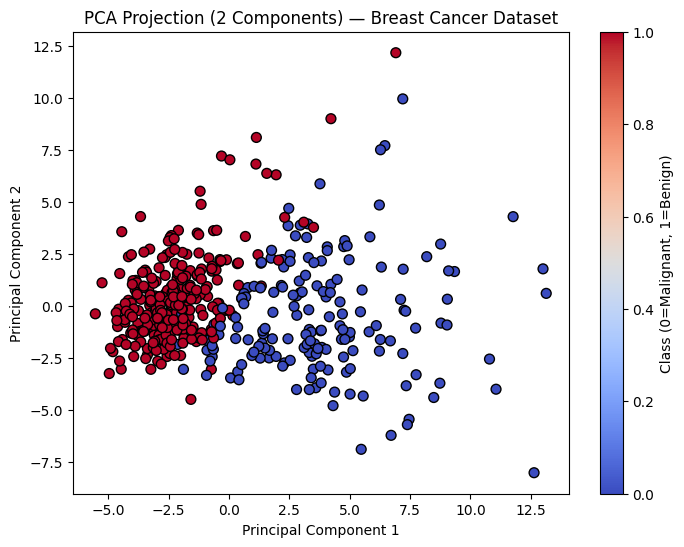


===== COMPARISON =====
             Model  Accuracy Variance Retained
0  LogReg (No PCA)  0.982456              100%
1  LogReg (PCA-2D)  0.947368            63.36%


In [10]:
# PCA and Logistic Regression on Breast Cancer dataset
# Demonstrates dimensionality reduction + visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Original shape: {X.shape}")  # (569, 30)

# 2️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize features (important for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Logistic Regression WITHOUT PCA
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred)
print(f"\n🚀 Logistic Regression without PCA: {acc_no_pca:.4f}")

# 5️⃣ Apply PCA (reduce 30 → 2 components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# 6️⃣ Logistic Regression WITH PCA
log_reg_pca = LogisticRegression(max_iter=1000)
log_reg_pca.fit(X_train_pca, y_train)
y_pred_pca = log_reg_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"✅ Logistic Regression with PCA (2 components): {acc_pca:.4f}")

# 7️⃣ Visualization of PCA result
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap="coolwarm", edgecolor="k", s=50)
plt.title("PCA Projection (2 Components) — Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Class (0=Malignant, 1=Benign)")
plt.show()

# 8️⃣ Summary
summary = pd.DataFrame({
    "Model": ["LogReg (No PCA)", "LogReg (PCA-2D)"],
    "Accuracy": [acc_no_pca, acc_pca],
    "Variance Retained": ["100%", f"{pca.explained_variance_ratio_.sum()*100:.2f}%"]
})
print("\n===== COMPARISON =====")
print(summary)

Original shape: (569, 30)

🔹 Eigenvalues (variance captured by each component):
PC1: 13.3534
PC2: 5.6959
PC3: 2.8693
PC4: 2.0219
PC5: 1.6590

🔹 Eigenvectors (principal component directions):
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
PC1        0.218         0.095           0.226      0.220            0.149   
PC2       -0.239        -0.066          -0.220     -0.234            0.176   
PC3       -0.003         0.070          -0.004      0.030           -0.110   
PC4       -0.037         0.602          -0.038     -0.051           -0.174   
PC5        0.046        -0.082           0.044      0.019           -0.346   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
PC1             0.242           0.258                0.261          0.145   
PC2             0.144           0.064               -0.038          0.186   
PC3            -0.067           0.001               -0.031         -0.048   
PC4            -0.025          -

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/d

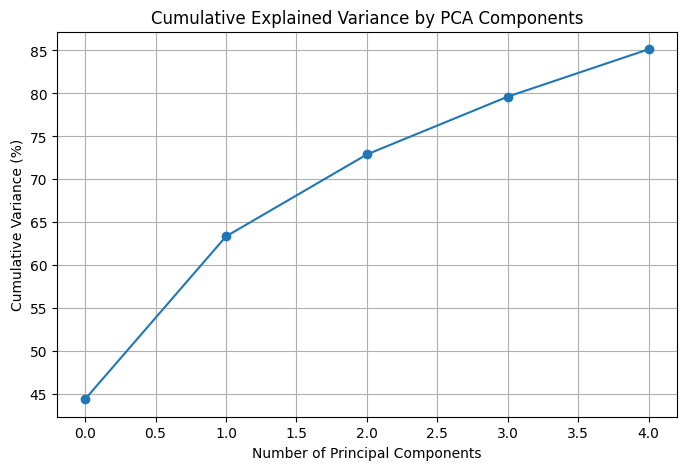


✅ Logistic Regression Accuracy (using 5 PCs): 0.9561


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1️⃣ Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
print(f"Original shape: {X.shape}")  # (569, 30)

# 2️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Apply PCA
pca = PCA(n_components=5)  # take top 5 PCs
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5️⃣ Eigenvalues and Eigenvectors
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("\n🔹 Eigenvalues (variance captured by each component):")
for i, val in enumerate(eigenvalues, start=1):
    print(f"PC{i}: {val:.4f}")

print("\n🔹 Eigenvectors (principal component directions):")
eig_df = pd.DataFrame(
    eigenvectors,
    columns=feature_names,
    index=[f"PC{i}" for i in range(1, len(eigenvectors) + 1)]
)
print(eig_df.round(3))

# 6️⃣ Explained variance ratio (fraction of total variance per component)
print("\n🔹 Explained Variance Ratio (%):")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio*100:.2f}%")

# 7️⃣ Cumulative variance plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance (%)")
plt.grid(True)
plt.show()

# 8️⃣ Logistic Regression on PCA data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_pca, y_train)
y_pred = log_reg.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Logistic Regression Accuracy (using {pca.n_components_} PCs): {acc:.4f}")